In [1]:
from GWForge.population.mass import Mass
import numpy as np
import configparser

In [2]:
hyperpar_ini_file = 'pdb_hyperpar_defaults.ini'

In [3]:
cfg = configparser.ConfigParser()
# preserve key case from INI (case-sensitive keys)
cfg.optionxform = str
cfg.read(hyperpar_ini_file)
sec = cfg['hyperparameters']

# Load entire INI section as float-valued hyperparameters dictionary
hyperparams = {k: float(v) for k, v in sec.items()}
print("Loaded hyperparameters from INI file:", hyperparams)
hyperparams['mmin'] = 0.5
hyperparams['mmax'] = 350.0

Loaded hyperparameters from INI file: {'alpha_1': -4.509282643557759, 'alpha_dip': -1.6797692040029513, 'alpha_2': -0.9020346791414204, 'NSmin': 1.1763665089045245, 'NSmax': 4.094744137742966, 'BHmin': 7.7639549426962375, 'BHmax': 152.05597923492775, 'UPPERmin': 38.277415427531, 'UPPERmax': 66.57670527299628, 'n0': 50.0, 'n1': 50.0, 'n2': 50.0, 'n3': 30.0, 'n4': 30.0, 'n5': 10.041072204811995, 'mix1': 735.473275543081, 'mu1': 37.811196396328114, 'sig1': 17.12643064109277, 'mix2': 211.73332682799375, 'mu2': 8.897742041719734, 'sig2': 1.044692632025516, 'A': 0.091462424745936, 'A2': 0.8281652204882891, 'beta_pair_1': 0.9641379639323953, 'beta_pair_2': 2.160035650137072, 'mbreak': 5.0}


In [4]:
hyperparams.keys()

dict_keys(['alpha_1', 'alpha_dip', 'alpha_2', 'NSmin', 'NSmax', 'BHmin', 'BHmax', 'UPPERmin', 'UPPERmax', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'mix1', 'mu1', 'sig1', 'mix2', 'mu2', 'sig2', 'A', 'A2', 'beta_pair_1', 'beta_pair_2', 'mbreak', 'mmin', 'mmax'])

In [5]:
mass_model = Mass(mass_model='FullPop_GWTC4', 
                  number_of_samples=50000, 
                  parameters=hyperparams, 
                  max_iterations=10000)

In [6]:
mass_samples = mass_model.sample()

2026-02-20 11:20:01 Generating samples using fullpopgwtc4 model


Estimated maximum probability: 0.003387992175079073
Starting rejection sampling for 50000 samples...


Sampling: 100%|██████████| 50000/50000 [00:02<00:00, 20127.57samples/s]
2026-02-20 11:20:04 Rejection sampling acceptance rate: 0.0125


Sampling complete!
Generated 50000 samples (requested 50000)
Total proposals: 4012340
Acceptance rate: 0.0125


In [7]:
mass_samples

{'mass_1_source': array([ 8.39688856,  3.99565632,  8.63366572, ...,  2.68198496,
         9.88840613, 32.24338159]),
 'mass_2_source': array([1.37312876, 1.6955151 , 1.88566804, ..., 2.36819523, 2.24408041,
        1.26212099]),
 'chirp_mass_source': array([2.74864546, 2.22583793, 3.3311841 , ..., 2.1931227 , 3.89860164,
        4.57827332]),
 'total_mass_source': array([ 9.77001732,  5.69117142, 10.51933376, ...,  5.05018019,
        12.13248653, 33.50550258]),
 'symmetric_mass_ratio': array([0.12079223, 0.20916377, 0.14712416, ..., 0.24903483, 0.15075269,
        0.03625011]),
 'mass_ratio': array([0.16352828, 0.42433957, 0.21840874, ..., 0.88300094, 0.22694056,
        0.03914357])}

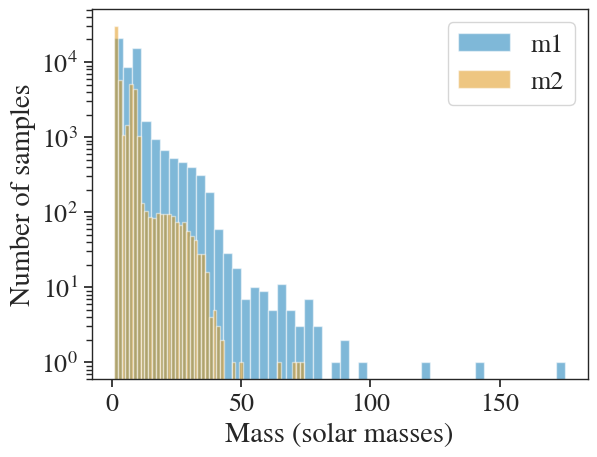

In [8]:
import pylab as plt
plt.hist(mass_samples['mass_1_source'], bins=50, alpha=0.5, label='m1')
plt.hist(mass_samples['mass_2_source'], bins=50, alpha=0.5, label='m2')
plt.xlabel('Mass (solar masses)')
plt.ylabel('Number of samples')
plt.yscale('log')
plt.legend()

## Compare with Fig. 2 of GWTC-4 population paper

In [9]:
import popsummary
pdb_file = '../../../data/GWTC-4_pop/analyses_AllCBC/AllCBC_FullPop.h5'
pdb_result = popsummary.popresult.PopulationResult(fname=pdb_file)

opening existing popsummary file: ../../../data/GWTC-4_pop/analyses_AllCBC/AllCBC_FullPop.h5


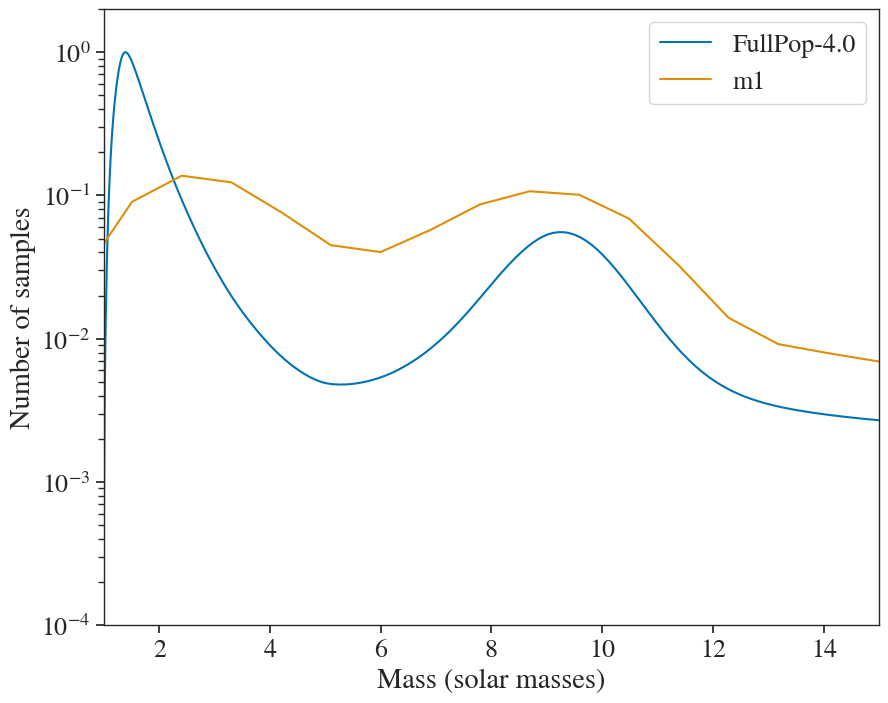

In [13]:
import seaborn as sns
import pylab as plt

plt.figure(figsize=(10,8))
pdb_m, pdb_Rm = pdb_result.get_rates_on_grids('primary_mass')
yy = np.mean(pdb_Rm, axis=0)/np.max(np.mean(pdb_Rm, axis=0))
plt.plot(pdb_m[0], yy, label='FullPop-4.0')

sns.kdeplot(mass_samples['mass_1_source'], label='m1')
plt.xlabel('Mass (solar masses)')
plt.ylabel('Number of samples')
plt.yscale('log')
plt.ylim(1e-4, 2)
plt.xlim(1,15)
plt.legend()